<span style="color:red;font-size:2em;font-weight:bold"> PARTIE4 - Optimisation des hyperparamètres et du seuil de validation</span>

<span style="color:blue;font-size:1.5em;font-weight:bold;background-color:yellow"> Modules </span>

In [1]:
# Module pour recharger un module sans redemarrer le kernel
# import importlib
%load_ext autoreload
%autoreload 2

In [2]:

# Roots
import numpy as np
import pandas as pd
import joblib
import json
import matplotlib.pyplot as plt
from pathlib import Path

from scipy.stats import loguniform

#Selection
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV, 
    StratifiedKFold,
)
# Metrics
from sklearn.metrics import (
    confusion_matrix, fbeta_score,
    precision_score, recall_score,
    make_scorer, ConfusionMatrixDisplay
)

# Feature importance
from sklearn.inspection import permutation_importance

#Modèles
from sklearn.ensemble import (
    HistGradientBoostingClassifier
)

In [3]:
# Sert à éviter les Warnings avec les transformations sur des vues en transformant 
# ces warning en erreur obligeant ainsi à ne travailler que sur des copies ou les originaux.

pd.set_option('mode.chained_assignment','raise')

In [4]:
# Ajoute le dossier datas_manipulation au sys.path. Remarque ne pas oublier le __init__.py dans le dossier datas_manipulation
import sys
# root_path = Path(__file__).resolve().parents[1] # Ne fonctionne pas sur notebook
root_path = Path.cwd().parent
sys.path.append(str(root_path))

In [ ]:
# Fonctions personnelles

# utils
from notebooks.utils.features_type_list import features_type
from notebooks.models_tools.model_attributes import predict_proba_wrapper
from notebooks.models_tools.threshold_tuning import optimize_threshold,cost_function
from notebooks.datas_manipulation.export_datas import export_datas

# pipeline
from notebooks.models_tools.pipeline_builder import build_classification_pipeline

# préprocessing
from notebooks.models_tools.preprocessing import (
    preproc_numerical_features,
    build_preprocessor
)

# modeling
from notebooks.models_tools.modelisation import modeling_cv, predict_models_cv

# plots
from notebooks.plotting.make_model_plots import (
    get_feature_importance, 
    plot_feature_importance, 
    plot_hyperparam_effect,
    pr_curve
)
from notebooks.plotting.config_figures import save_figure


In [6]:

# Paramètres globaux

# Création dossier results
save_path = root_path.joinpath('datas/results')
Path.mkdir(save_path,exist_ok = True)

# variables globales
random_state=42
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=random_state
)
# n_jobs: Number of jobs to run in parallel. 
# Training the estimator and computing the score are parallelized 
# over the cross-validation splits. 
# None means 1 unless in a joblib.parallel_backend context. 
# -1 means using all processors.
n_jobs = -1

# test size
test_size = 0.2

# early_stopping validation_fraction
early_stopping_val_frac = 0.1

<span style="color:blue;font-size:1.5em;font-weight:bold;background-color:yellow"> Traquer les expérimentations avec MLFlow </span>

In [7]:
# import
import mlflow

# ================== Ce qui est dit sur la docs de MLFlow ==============
# 1. Config Tracking
# database en local (sqlite)
# mlflow.set_tracking_uri("sqlite:///mlflow.db")
# mlflow.set_experiment("my-first-experiment")
# database distant
# # Connect to remote MLflow server
# mlflow.set_tracking_uri("http://localhost:5000")
# mlflow.set_experiment("my-first-experiment")
# # ou
# export MLFLOW_TRACKING_URI="http://localhost:5000"
# export MLFLOW_EXPERIMENT_NAME="my-first-experiment"
# =====================================================================

mlflow.set_tracking_uri("sqlite:///mlflow.db")
# On définie l'experiment
experiment_name = "Home_Credit"
mlflow.set_experiment(experiment_name)

2026/01/29 12:11:08 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/01/29 12:11:08 INFO mlflow.store.db.utils: Updating database tables
2026/01/29 12:11:08 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/29 12:11:08 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/01/29 12:11:08 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/29 12:11:08 INFO alembic.runtime.migration: Will assume non-transactional DDL.


<Experiment: artifact_location='/home/shipoz/Documents/OPENCLASSROOMS/P6/livrable_P6/notebooks/mlruns/1', creation_time=1769641154642, experiment_id='1', last_update_time=1769641154642, lifecycle_stage='active', name='Home_Credit', tags={}>

In [8]:
# 2. Vérif connexion

print(f"MLflow Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Active Experiment: {mlflow.get_experiment_by_name('Home_Credit')}")

# Test logging
with mlflow.start_run():
    mlflow.log_param("test_param", "test_value")
    print("✓ Successfully connected to MLflow!")

MLflow Tracking URI: sqlite:///mlflow.db
Active Experiment: <Experiment: artifact_location='/home/shipoz/Documents/OPENCLASSROOMS/P6/livrable_P6/notebooks/mlruns/1', creation_time=1769641154642, experiment_id='1', last_update_time=1769641154642, lifecycle_stage='active', name='Home_Credit', tags={}>
✓ Successfully connected to MLflow!


**A lancer sur le terminal**
```python
# 3. Accès MLFlow UI

# For Option A (local database)
mlflow server \
    --backend-store-uri sqlite:///mlflow.db \
    --default-artifact-root ./mlruns \
    --host 127.0.0.1 \
    --port 5000
# # For Option B (distant database)
# If you have the remote tracking server running (option C), access the MLflow UI at the same URI.
```

In [9]:
# Enable autologging for scikit-learn
# Va save le modele, les metriques, les hyperparam et des métadonnées (temps, format...)
mlflow.sklearn.autolog() # type: ignore

<span style="color:blue;font-size:1.5em;font-weight:bold;background-color:yellow"> Datasets </span>

In [10]:
# Chemin du dataset d'entrainement/test du modèle
datas_path = (
    root_path /'datas'/'raw_datas'/
    'Projet+Mise+en+prod+-+home-credit-default-risk'/'final_datasets'
)

In [ ]:
# Importation de la donnée
Xy= pd.read_parquet(datas_path/"train.parquet").sample(frac=0.0005, random_state=42) # sample
# Xy= pd.read_parquet(datas_path/"train.parquet")
Xy.head()

In [12]:
Xy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31 entries, 245895 to 17719
Columns: 713 entries, SK_ID_CURR to CC_CC_ID_PREV_NAME_CONTRACT_STATUS_Signed_MIN
dtypes: float32(547), float64(138), int16(2), int8(12), object(14)
memory usage: 103.8+ KB


In [13]:
# Définition des prédicteurs X et de la cible y
X = Xy.drop(columns=['TARGET'])
y = Xy['TARGET']

In [14]:
# Identification des features numériques et catégorielles
num_list, cat_list = features_type(X)

In [15]:
# train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=test_size, 
    stratify=y, #Stratifie la proportion de y pour un unique split
    random_state=random_state
)

<span style="color:blue;font-size:1.5em;font-weight:bold;background-color:yellow"> Configurations </span>

<span style="color:blue;font-weight:bold">Modèle</span>

In [16]:
model = HistGradientBoostingClassifier(
        random_state= random_state,
        class_weight='balanced',
        early_stopping=True,
        validation_fraction=early_stopping_val_frac 
        # sert a valider le early_stopping ou pas en comparant les métriques du jeu-fracton avec la fraction
    )

<span style="color:blue;font-weight:bold">Métriques</span>

In [17]:
scoring = {
        'f2':make_scorer(fbeta_score, beta=2, zero_division=0),
        'precision':make_scorer(precision_score, zero_division=0),
        'recall':make_scorer(recall_score, zero_division=0),
    }

<span style="color:blue;font-weight:bold">Pipeline et grille de distribution</span>

Remarque: Si on était resté sur la même session/notebook que la partie précédente il n'aurait pas été nécéssaire de redéfinir la pipeline et il suffirait de rappelé la pipeline du candidat choisit (candidate_pipe = pipelines[candidate])

In [18]:
# Preprocessing

# Matrice dense sans scaling (RF, GradientBoosting, HistGB)
no_scaling = preproc_numerical_features()

preproc_noScale_dense = build_preprocessor(
    numeric_features=num_list, 
    categorical_features=cat_list,
    num_pipeline=no_scaling,
    sparse_output=False
)

In [19]:
# Pipeline

hgb_pipe = build_classification_pipeline(model,preproc_noScale_dense)

In [20]:
# Grille de distribution des hyperparamètres d'études
prefix_step = "classifier__" # Pipeline == prefixe complementaire suivant la profondeur
param_distrib = {
    f'{prefix_step}max_depth':np.arange(2,7), # Profondeur de l'arbre /  risque d'overfit si important (defaut None)
    f'{prefix_step}learning_rate':loguniform(0.02,0.08), # Influence vit d'apprent/ Très sensible / bas = stable mais couteux (defaut 0.1)
    f'{prefix_step}max_iter' :np.arange(100,800,100),# Nb max d'arbres / 300---500 par pas de 100 / à combiner avec early_stopping (defaut 100)
    f'{prefix_step}l2_regularization':loguniform(1e-3,10.0), # Coeff pour le terme L2 de regul de la fonction de cout (defaut 0)
    # (ecart entre y_pred et y_test pdt train) 
    # Controle l'ajustement du modèle face aux données notamment du bruit)
    f'{prefix_step}min_samples_leaf':[20,50,100,200,400]
}

Remarque: En présence de pipeline, le nom de l'étape (preproc, sampler, model) est rattaché comme suffix aux hyperparamètres. plus il y a de sous-pipeline plus le prefix grandit.

<span style="color:blue;font-size:1.5em;font-weight:bold;background-color:yellow"> Modélisation </span>

In [21]:
# On définie l'experiment
experiment_name = "Optimisation_modele"
mlflow.set_experiment(experiment_name)

<Experiment: artifact_location='/home/shipoz/Documents/OPENCLASSROOMS/P6/livrable_P6/notebooks/mlruns/2', creation_time=1769641164640, experiment_id='2', last_update_time=1769641164640, lifecycle_stage='active', name='Optimisation_modele', tags={}>

In [22]:
# # Désactive le log des modèles pendant la CV pour éviter les sous-runs
# mlflow.sklearn.autolog(disable = True) #type:ignore

In [23]:
# START_RUN
mlflow.start_run(run_name="HGB_optimisation_hyperparamètres")

<ActiveRun: >

<span style="color:blue;font-size:1.5em;font-weight:bold;background-color:yellow">Optimisation des hyperparamètres</span>

Pour étudier les hyperparam afin de sotir le meilleur modèle parmi ceux testé on va devoir réaliser des combinaisons de ces paramètres, modéliser et comparer les performances.

Dans notre cas, on a 5 hyperparamètres, sans compter les loguniform (disons 5 valeurs) on aurait $5x5x7x5x5 = 4375$ combinaisons multiplié par cv = 3 et hypothétiquement 100 secondes en moyennes par simulation ( temps de base du hgb précédemment) il faudrait environ 364 heures de calculs ==> IMPOSSIBLE. Solution? On utilise à la place de GridSearchCV, **RandomizedSearchCV**, on peut ainsi limiter le nombre de combinaisons et l'aléatoire se chargera de choisir les combinaisons dans le spectre donné.

In [ ]:
# ==================== Configuration de RSCV ====================
random_search = RandomizedSearchCV(
    estimator = hgb_pipe,
    param_distributions = param_distrib,
    scoring = scoring,
    refit = 'f2', # choix de la métrique de  controle
    n_iter  = 20, # Contrôle le nombre de combinaison max
    cv = cv,
    n_jobs = n_jobs, # calcul parallèle
    random_state = random_state,
    return_train_score = True,
    verbose = 2, # Affiche temp de calcul pour chaque fold avec param candidat + le score
)

In [25]:
# Entrainement et determination de l'optimum
random_search.fit(X_train,y_train)

2026/01/29 12:11:19 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/shipoz/Documents/OPENCLASSROOMS/P6/livrable_P6/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END classifier__l2_regularization=0.03148911647956861, classifier__learning_rate=0.07471658997996457, classifier__max_depth=4, classifier__max_iter=500, classifier__min_samples_leaf=400; total time=   0.3s
[CV] END classifier__l2_regularization=0.03148911647956861, classifier__learning_rate=0.07471658997996457, classifier__max_depth=4, classifier__max_iter=500, classifier__min_samples_leaf=400; total time=   0.3s
[CV] END classifier__l2_regularization=0.03148911647956861, classifier__learning_rate=0.07471658997996457, classifier__max_depth=4, classifier__max_iter=500, classifier__min_samples_leaf=400; total time=   0.3s
[CV] END classifier__l2_regularization=0.004207988669606638, classifier__learning_rate=0.02482836122297175, classifier__max_depth=4, classifier__max_iter=300, classifier__min_samples_leaf=400; total time=   0.3s
[CV] END classifier__l2_regularization=0.004207988669606638, classifier__learning_rate=0.02482

2026/01/29 12:11:36 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/shipoz/Documents/OPENCLASSROOMS/P6/livrable_P6/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
/home/shipoz/Documents/OPENCLASSROOMS/P6/livrable_P6/.venv/lib/python3.12/site-packages/sklearn/metrics/_classifi

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__l2_regularization': <scipy.stats....x70e22c70d370>, 'classifier__learning_rate': <scipy.stats....x70e234fbac00>, 'classifier__max_depth': array([2, 3, 4, 5, 6]), 'classifier__max_iter': array([100, 2...00, 600, 700]), ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'f2': make_scorer(f...ro_division=0), 'precision': make_scorer(p...ro_division=0), 'recall': make_scorer(r...ro_division=0)}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allo

In [26]:
# ======================= LOGGING ======================================
best_model_optHyperparams = random_search.best_estimator_

# Logging des meilleurs params avec opt des hyperparams
mlflow.log_params(random_search.best_params_)
mlflow.log_metric("optHyperparams_f2", random_search.best_score_)
joblib.dump(best_model_optHyperparams, 'best_model.pkl')
mlflow.sklearn.log_model(sk_model=best_model_optHyperparams,name="best_model")#type:ignore
mlflow.set_tag("optHyperparams", "Résultats avec HGB après optimisation hyperparams")

<span style="color:blue;font-weight:bold"> Visualisation </span>

hyperParamEffect sauvegardé dans /home/shipoz/Documents/OPENCLASSROOMS/P6/livrable_P6/datas/results/figures


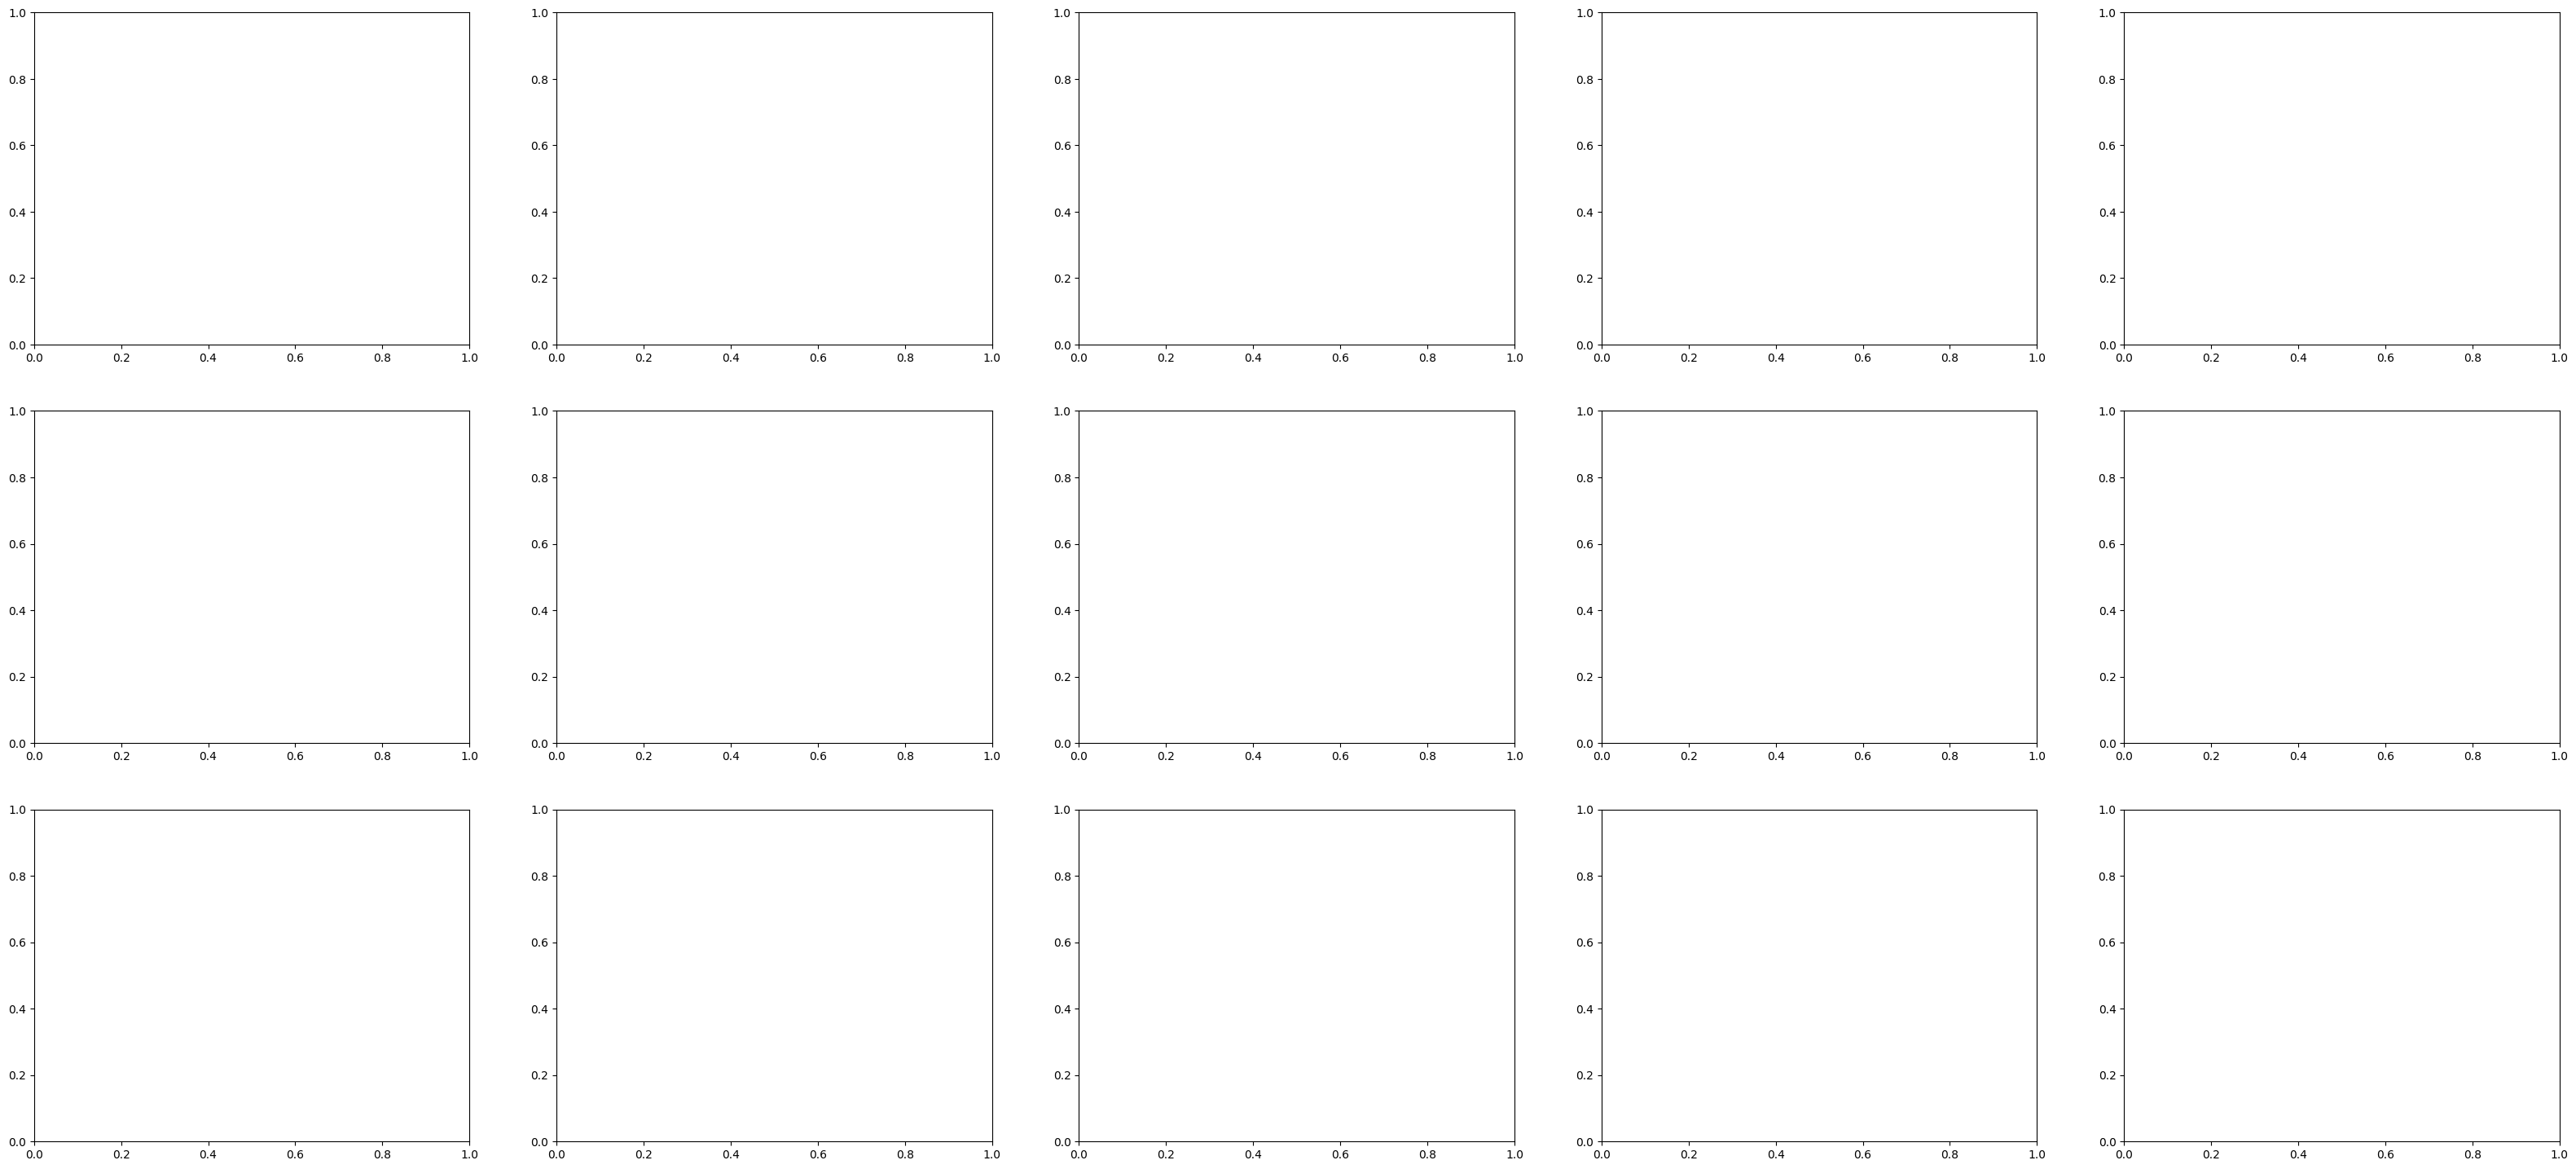

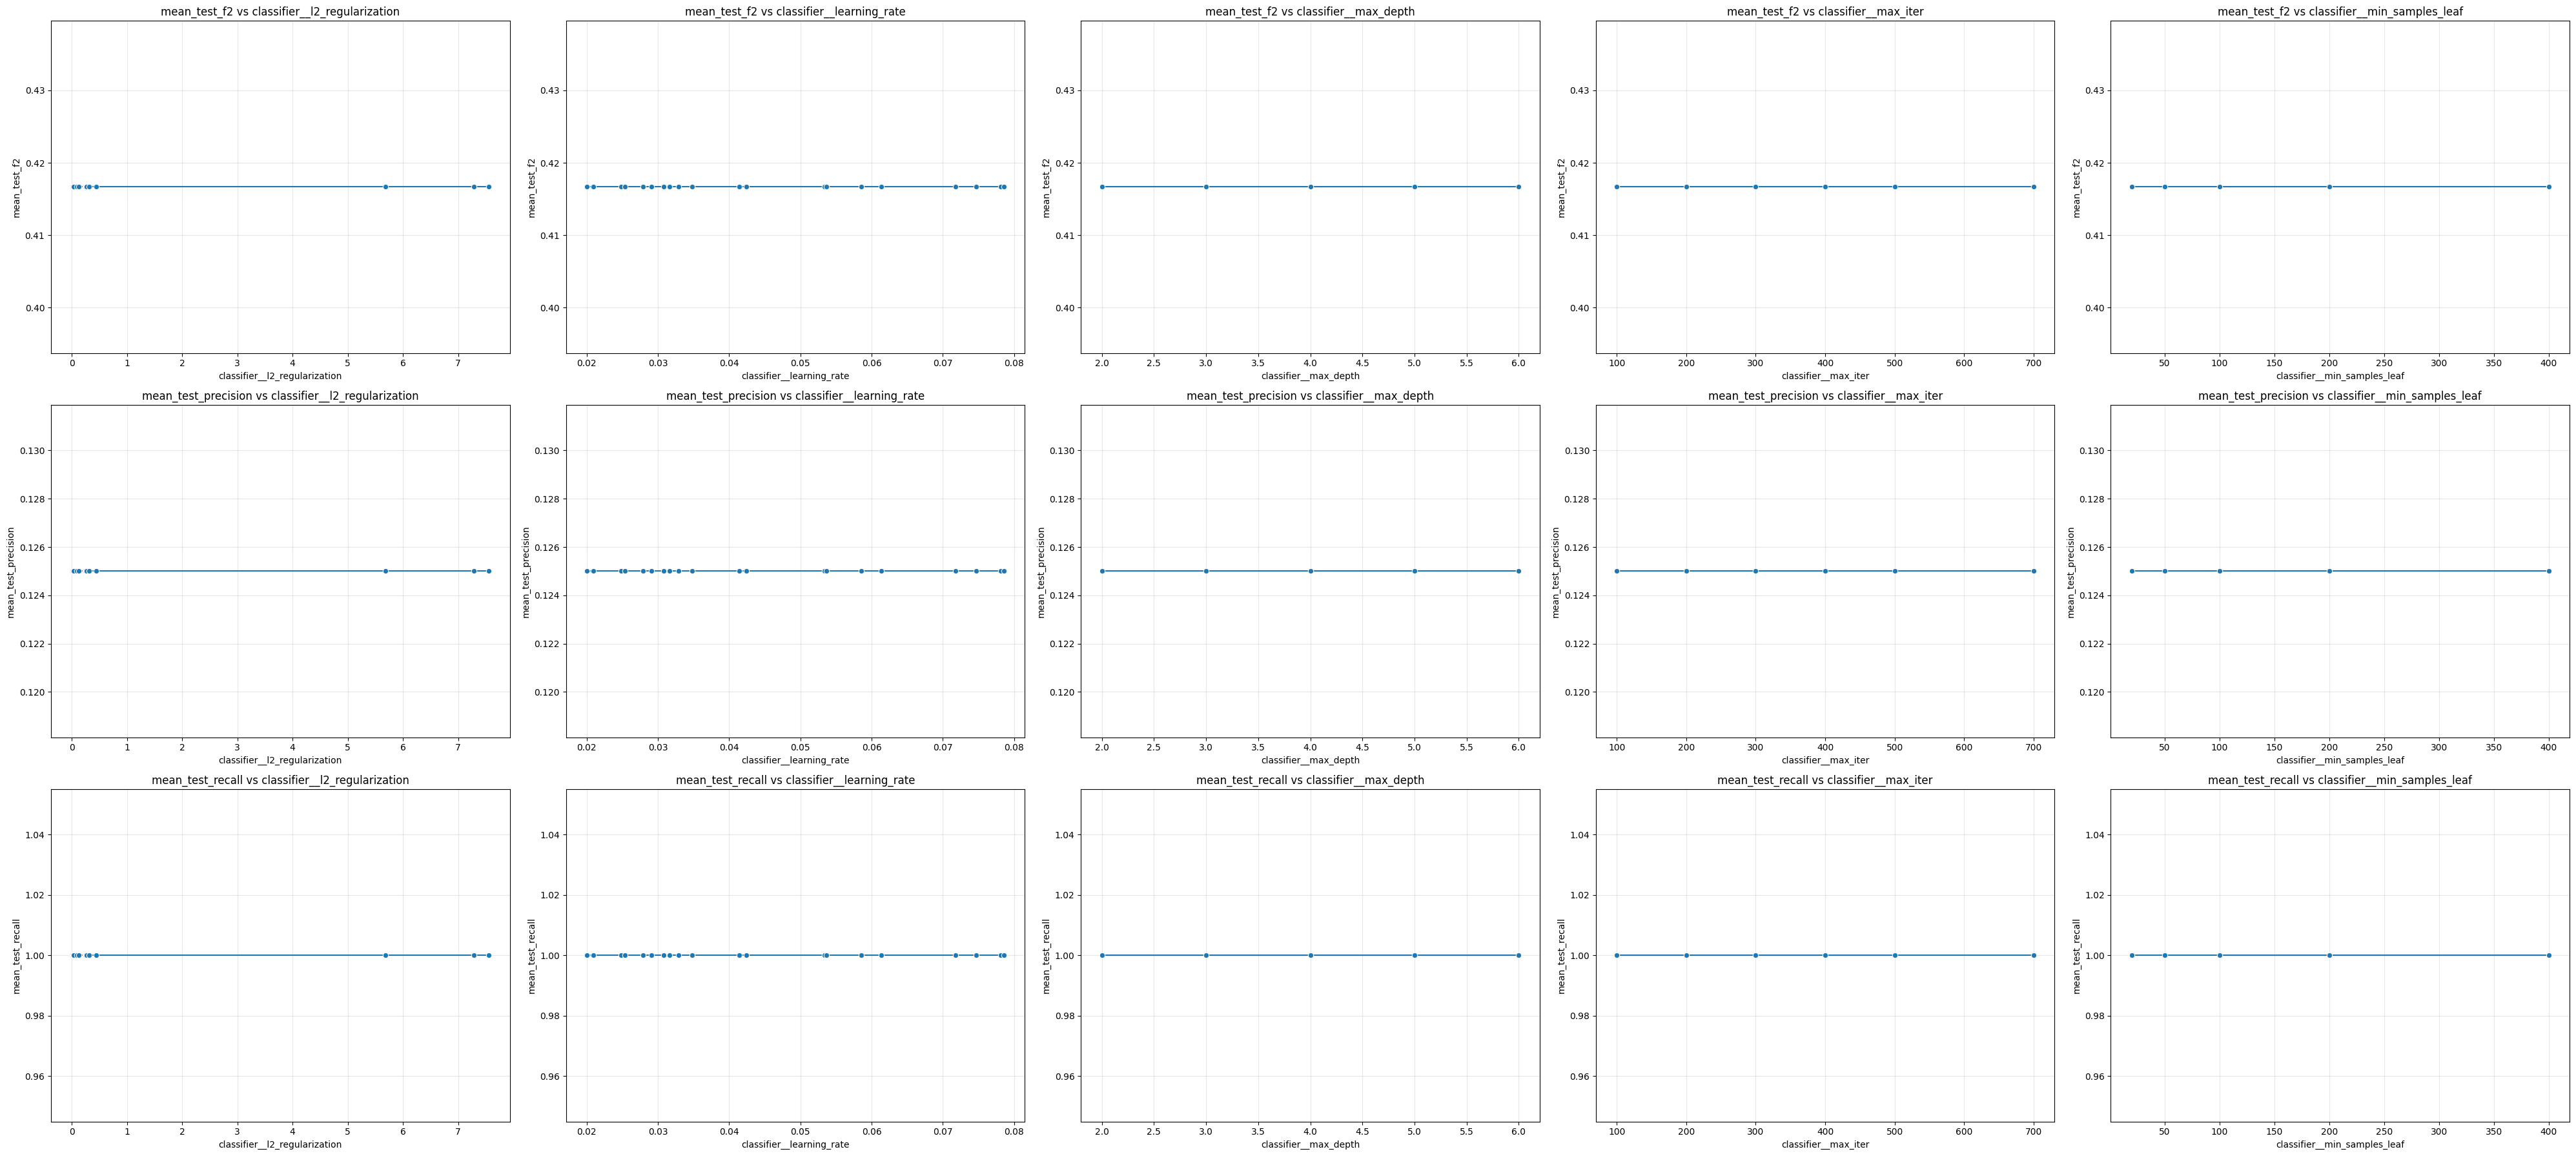

In [28]:
# ===================== VISUALISATION & METRIQUES ============================
# On construit la df des résultats du RSCV
rscv_results = pd.DataFrame(random_search.cv_results_)

# plot des effets des hyperparam
hyperparam_fig = plot_hyperparam_effect(
    rscv_results,
    model_type="classification",
    title_save="hyperParamEffect",
    save_path = save_path/"figures"
)


plt.show()

In [29]:
# ======================= LOGGING ======================================

# sauvegarde de la figure dans les artefacts de mlflow
mlflow.log_artifact(save_path/"figures/hyperParamEffect") # type: ignore

In [30]:
# END_RUN()
mlflow.end_run()

In [31]:
# # réactive le log des modèles après CV
# mlflow.sklearn.autolog(disable = False) #type:ignore

<span style="color:blue;font-size:1.5em;font-weight:bold;background-color:yellow">Optimisation du seuil de validation</span>

In [32]:
# # Désactive le log des modèles pendant la CV pour éviter les sous-runs
# mlflow.sklearn.autolog(disable = True) #type:ignore

In [33]:
# START_RUN
mlflow.start_run(run_name="HGB_optimisation_threshold")

<ActiveRun: >

In [ ]:
# ===================== PREDICT PROBA ============================
# calcul des probas sur le jeu holdout/test
y_test_pred_proba = random_search.predict_proba(X_test)[:,1]

# calcul des courbes alignées
precisions, recalls, thresholds, pr_auc = pr_curve(y_test, y_test_pred_proba)

# ====================== sans fonction de cout/ cout métier explicite
# # Optimisation du seuil
# pred_proba_results = optimize_threshold(
#     precisions, 
#     recalls,
#     thresholds,
#     method="fbeta", 
#     beta=2.0
# )
# optimal_thresh = pred_proba_results['optimal_threshold']

# ============ En prenant en compte le coût métier ================
thresholds_list = np.linspace(0.1, 0.9, 801)
costs = []

for threshold in thresholds_list:
    # Calcul du coût pour chaque seuil
    y_pred = (y_test_pred_proba >= threshold).astype(int)
    cost,tn, fp, fn, tp = cost_function(y_test, y_pred,cost_fn=10,cost_fp=1)
    costs.append(cost)
# indice associé à la valeur min de cout
best_idx = int(np.argmin(costs))

# threshold équivalent
optimal_thresh = float(thresholds_list[best_idx])
# coût associé
min_cost = float(costs[best_idx])

# f2 au seuil optimal de coût pour le logging
y_test_pred = (y_test_pred_proba >= optimal_thresh).astype(int)
f2_test = float(fbeta_score(y_test, y_test_pred, beta=2))

2026/01/29 15:42:24 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/shipoz/Documents/OPENCLASSROOMS/P6/livrable_P6/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


In [61]:
# ======================= LOGGING ======================================

mlflow.log_metric("pr_auc", pr_auc)
mlflow.log_metric("optThreshold", float(optimal_thresh))
# =============
# mlflow.log_metric("f2_associe", float(pred_proba_results["best_f_score"]))
mlflow.log_metric("f2_associe", f2_test)
# =============
config = {
    "threshold": float(optimal_thresh),
    "model": "HistGradientBoosting",
    "pr_auc":pr_auc,
    # =============
    # "f2":float(pred_proba_results["best_f_score"])
    "f2":f2_test
    # =============
}
with open("opt_thresh.json", "w") as f:
    json.dump(config, f)

<span style="color:blue;font-weight:bold"> Visualisation </span>

/tmp/ipykernel_4314/615030705.py:13: RuntimeWarning: invalid value encountered in scalar divide
  tp/(tp+fn), tp/(tp+fp), # Recall, Precision


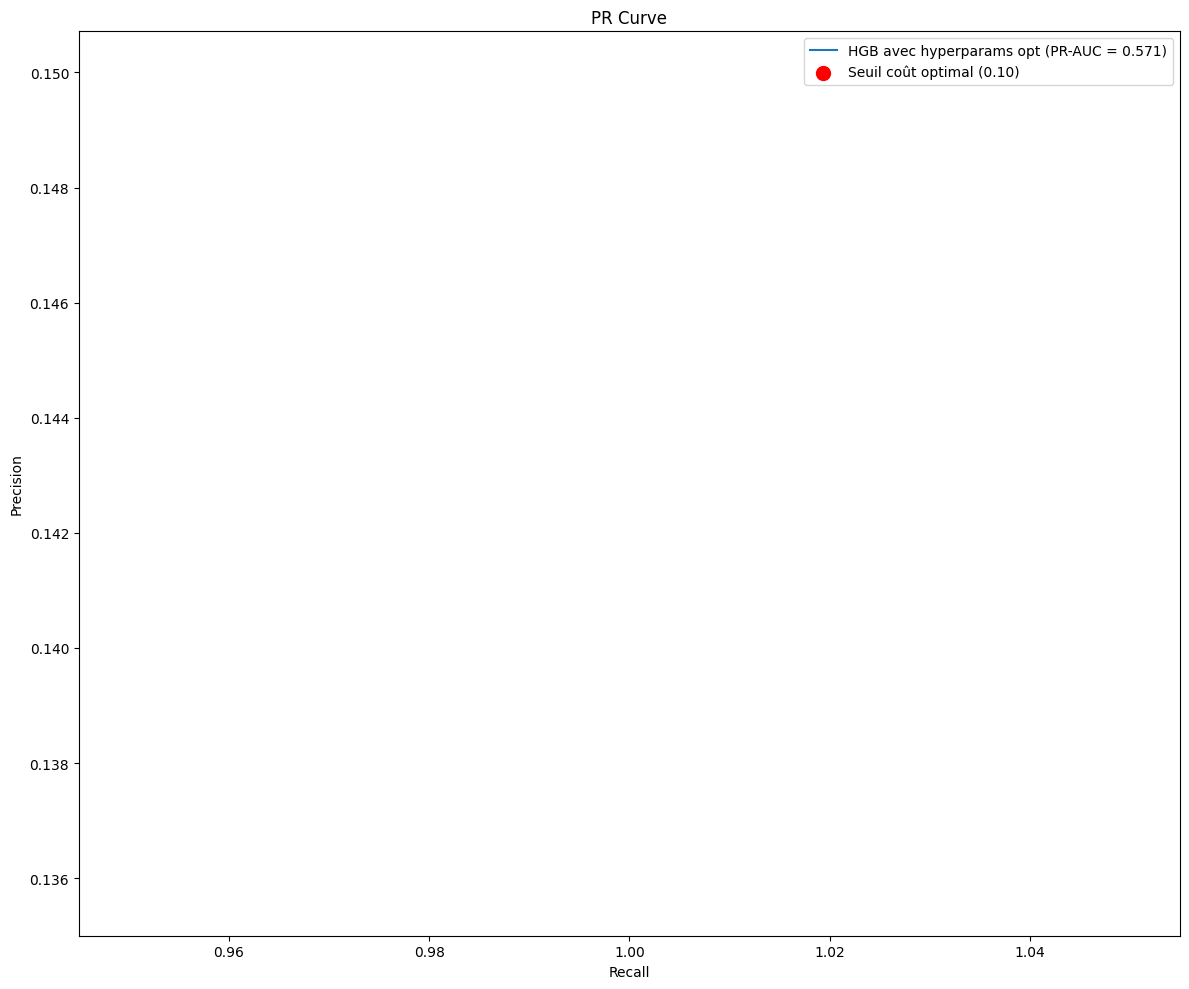

In [ ]:
# ===================== VISU & METRIQUES ============================
# Tracé
threshold_fig, ax = plt.subplots(figsize=(12,10))
ax.plot(recalls, precisions, label=f'HGB avec hyperparams opt (PR-AUC = {pr_auc:.3f})')
# =============
# ax.scatter(
#     pred_proba_results["recall"], pred_proba_results["precision"], 
#     c='red', s=100, 
#     label=f"Seuil optimal",
# )
tn_opt, fp_opt, fn_opt, tp_opt = confusion_matrix(y_test, y_test_pred).ravel()
ax.scatter(
    tp/(tp+fn), tp/(tp+fp), # Recall, Precision
    c='red', s=100, 
    label=f"Seuil coût optimal ({optimal_thresh:.3f})",
)
# =============
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('PR Curve')
ax.legend()

plt.tight_layout()
plt.show()

In [63]:
# ======================= LOGGING ======================================

# Sauvegarde de la courbe
save_figure("optThreshold_pr_curve", save_path/"figures")
# mlflow.log_artifact(str(save_path/"figures/comparaison_modeles_courbes_pr"))
mlflow.log_figure(threshold_fig, "optThreshold_pr_curve.png")

optThreshold_pr_curve sauvegardé dans /home/shipoz/Documents/OPENCLASSROOMS/P6/livrable_P6/datas/results/figures


<span style="color:blue;font-weight:bold"> Confirmation d'overfitting </span>

In [64]:
# ======================== Recherche d'overfitting ===============================
# f2 score rscv, le f2 donné par le meilleur modele avec hyperparamètres optimisés
f2_rscv = random_search.best_score_
# Calcul du Gap
gap = abs(f2_rscv - f2_test)


In [ ]:
# ======================= LOGGING ======================================

mlflow.log_metric("overfitting_gap", float(gap))
    
print(f" Analyse Overfitting (Métrique: F2-Score) :")
print(f"   - F2 RSCV (train) : {f2_rscv:.3f}")
print(f"   - F2 de référence (test) : {f2_test:.3f}")
print(f"   - Écart (Gap)          : {gap:.3f}")
if gap >=0.03:
    print('Overfitting potentiel')
    mlflow.set_tag("Status","Risque d'overfitting")
else:
    mlflow.set_tag("Status", "Pas d'overfitting")

 Analyse Overfitting (Métrique: F2-Score) :
   - F2 RSCV (train) : 0.4167
   - F2 de référence (test) : 0.4545
   - Écart (Gap)          : 0.0379
Overfitting potentiel


- f2_rscv renvoie la performance théorique du meilleur candidat.
- f2_test exprime la performance réelle attendue "dans la vraie vie".

Un écart (>0.03) va traduire un potentiel overfitting 

<span style="color:blue;font-weight:bold"> Matrice de confusion</span>

In [66]:
# ================ MATRICE DE CONFUSION (JEUX TEST/THRESHOLD OPT) ====================

# Prédiction avec seuil optimisé
# y_test_pred = (y_test_pred_proba >= optimal_thresh).astype(int) # deja présent plus haut
# prédiction avec seuil par défaut
y_test_pred_default = (y_test_pred_proba == 0.5).astype(int)

# matrice des confusion avec seuil par défaut et opt
#defaut
confusionMatrix_default = confusion_matrix(y_test, y_test_pred_default)
confusionMatrix_plot_default = ConfusionMatrixDisplay(
    confusion_matrix=confusionMatrix_default, 
    display_labels=['Solvable', 'Risque']
)
# opt
confusionMatrix = confusion_matrix(y_test, y_test_pred)
confusionMatrix_plot = ConfusionMatrixDisplay(
    confusion_matrix=confusionMatrix, 
    display_labels=['Solvable', 'Risque']
)

<span style="color:blue;font-weight:bold"> Visualisation </span>

<Figure size 640x480 with 0 Axes>

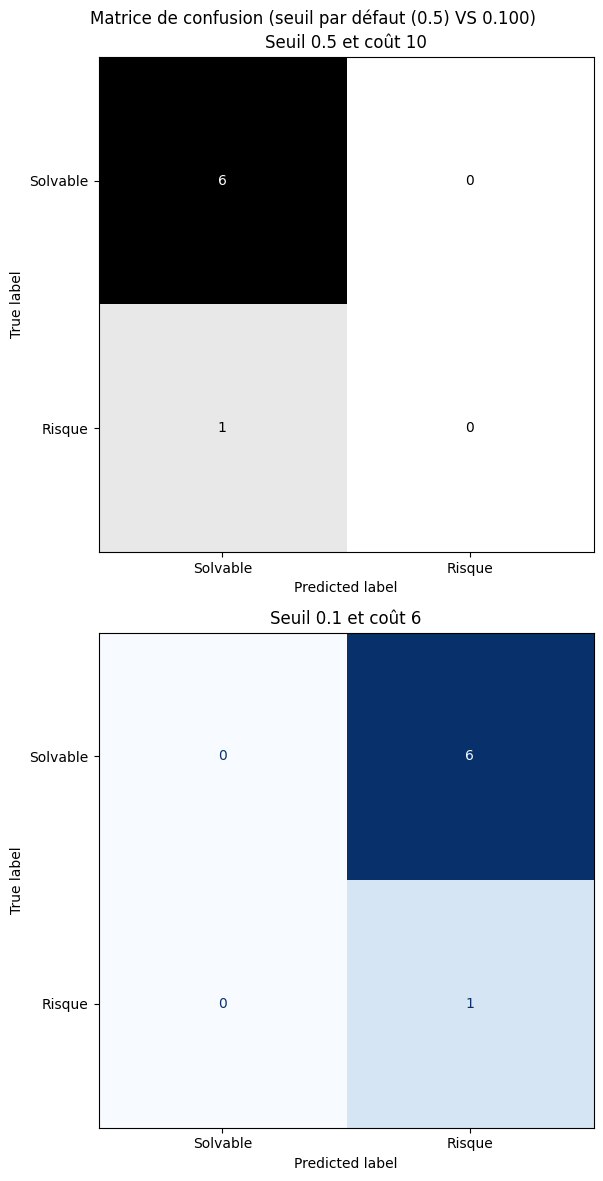

In [67]:
# ===================== VISU ==========================

confusionMatrix_fig, (ax_def, ax_opt) = plt.subplots(2, 1, figsize=(6, 12))

# defaut
confusionMatrix_plot_default.plot(ax=ax_def, cmap='Greys', colorbar=False)
ax_def.set_title(f"Seuil 0.5 et coût {fn*10+fp}", fontsize=12)

# opt
confusionMatrix_plot.plot(ax=ax_opt, cmap='Blues', colorbar=False)
ax_opt.set_title(f"Seuil {optimal_thresh} et coût {int(min_cost)}", fontsize=12)

plt.suptitle(f"Matrice de confusion (seuil par défaut (0.5) VS {optimal_thresh:.3f})")
plt.tight_layout()


plt.show()

In [68]:
# ======================= LOGGING ======================================

mlflow.log_figure(confusionMatrix_fig, "Matrice_confusion_jeux_test.png")

pour rappel:
- TP: client NON solvable et reconnu par le modèle
- TN: client solvable et detecté par le modèle
- FN: client NON solvable NON détécté par le modèle
- FP: client solvable NON détécté par le modèle

| TN (bon client) | FP (refusé à tort)
|----|------
| **FN (danger)** | **TP (refusé à raison)**

avec un FN >= 10x FP en terme de cout pour la banque.

In [69]:
# END_RUN()
mlflow.end_run()

In [70]:
# # réactive le log des modèles après CV
# mlflow.sklearn.autolog(disable = False) #type:ignore